DIMENSIONES DEL PANEL
Filas: 862
Columnas: 28

Columnas:
['Año', 'Mes', 'Estacion', 'NO2', 'O3', 'PM25', 'Cobertura_NO2', 'Cobertura_O3', 'Cobertura_PM25', 'valido_NO2', 'valido_O3', 'valido_PM25', 'Localidad', 'Fuente', 'Temp_media', 'HR', 'Vel_viento', 'Presión', 'Precipitación', 'Precipitación_media', 'lat', 'lon', 'dias_esperados', 'Cobertura_Temp', 'Cobertura_HR', 'Cobertura_Viento', 'Cobertura_Presion', 'Cobertura_Precip']

RANGO TEMPORAL
Fecha mínima: 2020-01-01 00:00:00
Fecha máxima: 2024-12-01 00:00:00
Número de meses únicos: 60
Número de estaciones únicas: 16
Número de localidades únicas: 11

RESUMEN GENERAL
  variable  no_nulos  faltantes  pct_faltante   media  mediana    min     max  \
0     PM25       856          6          0.70  16.243   15.556  2.703  48.272   
1      NO2       748        114         13.23  15.330   15.061  2.253  29.150   
2       O3       718        144         16.71  12.784   12.620  2.856  30.935   

   desv_std  validos_flag_true  validos_flag_fals

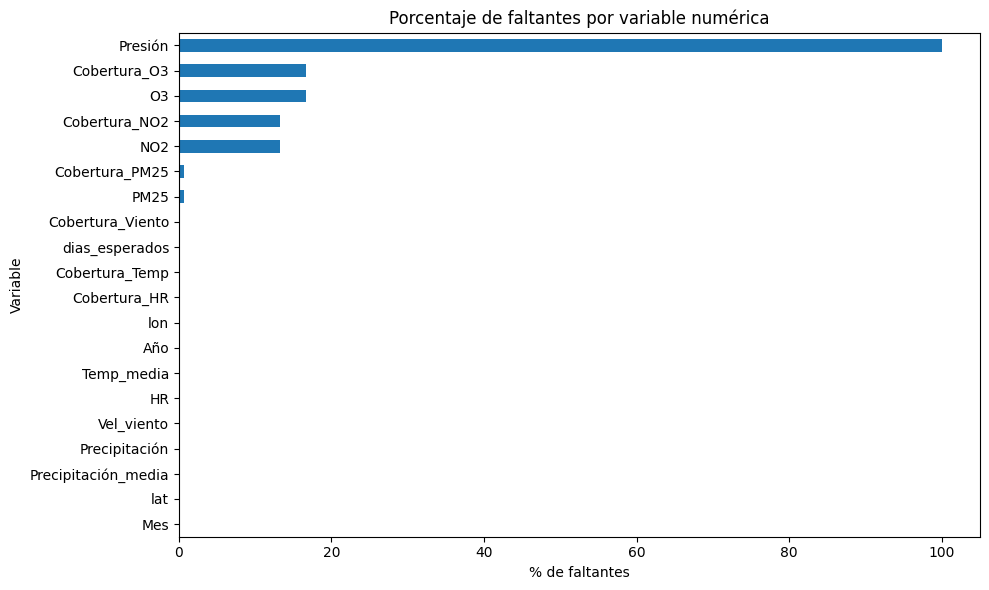

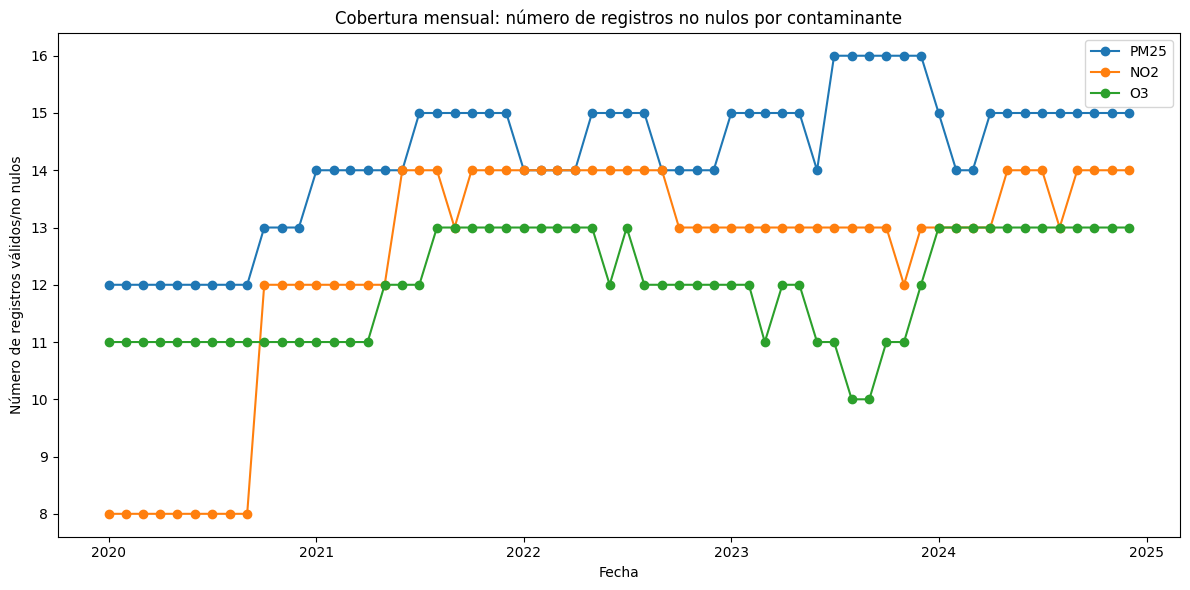

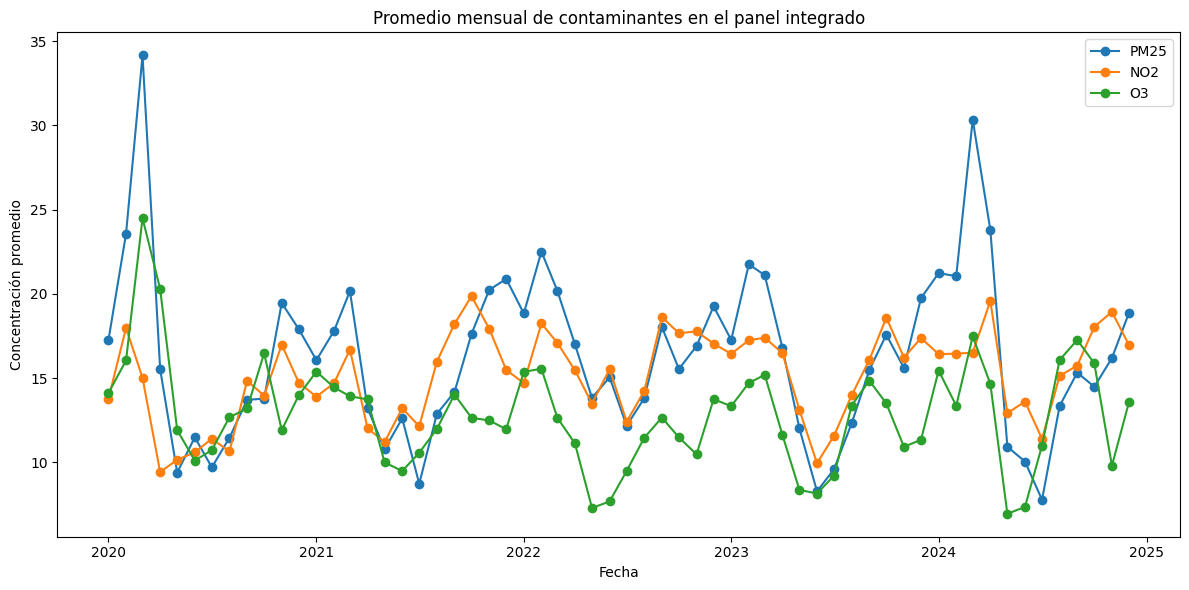

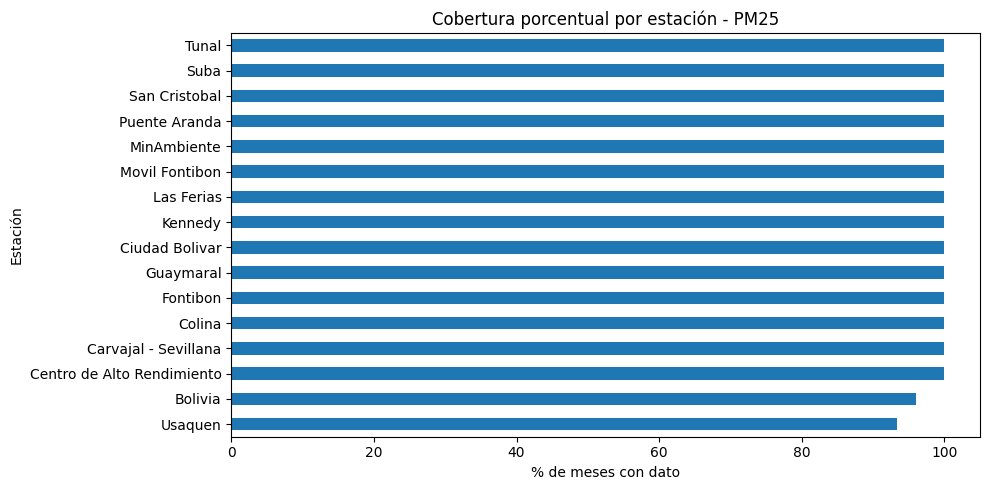

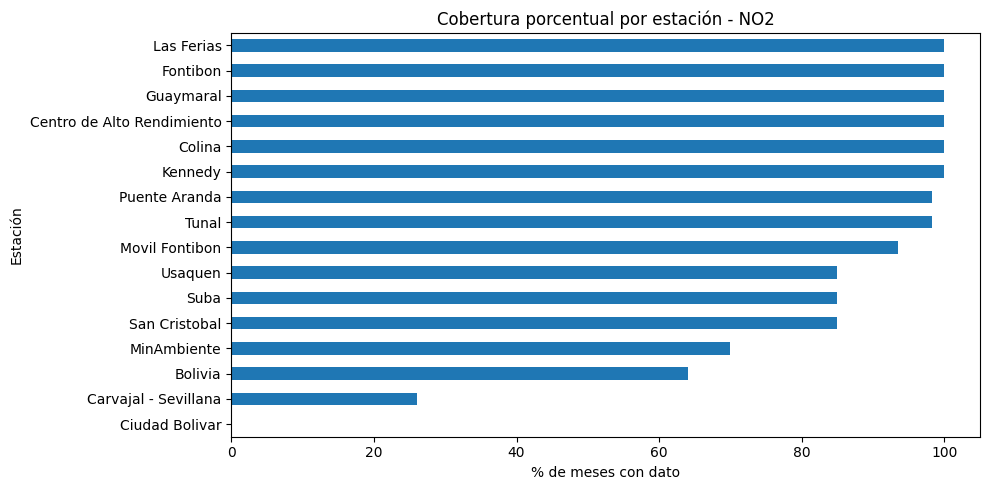

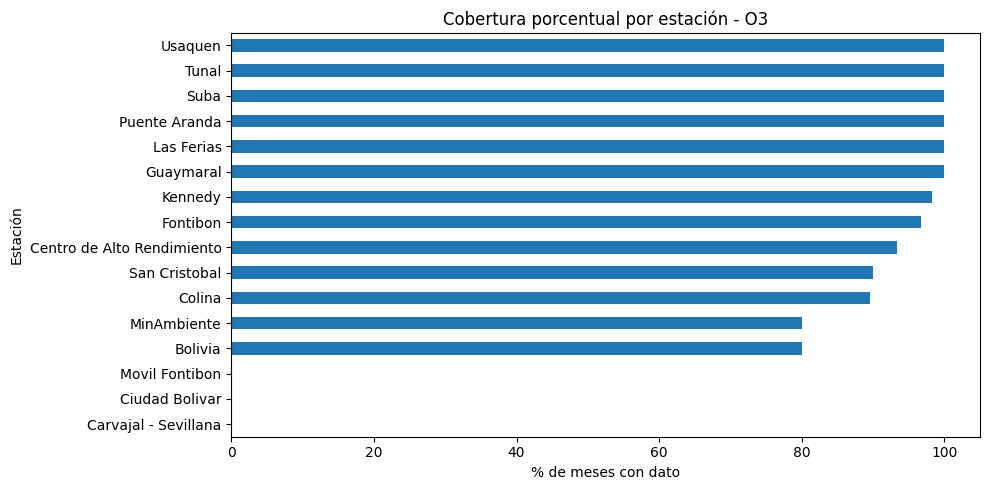

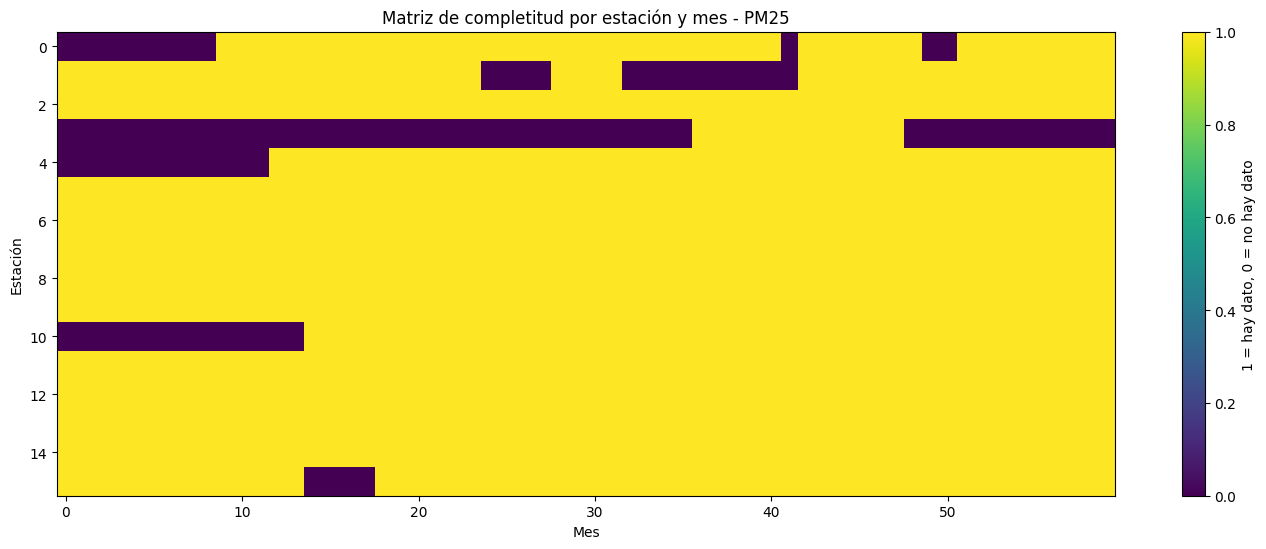

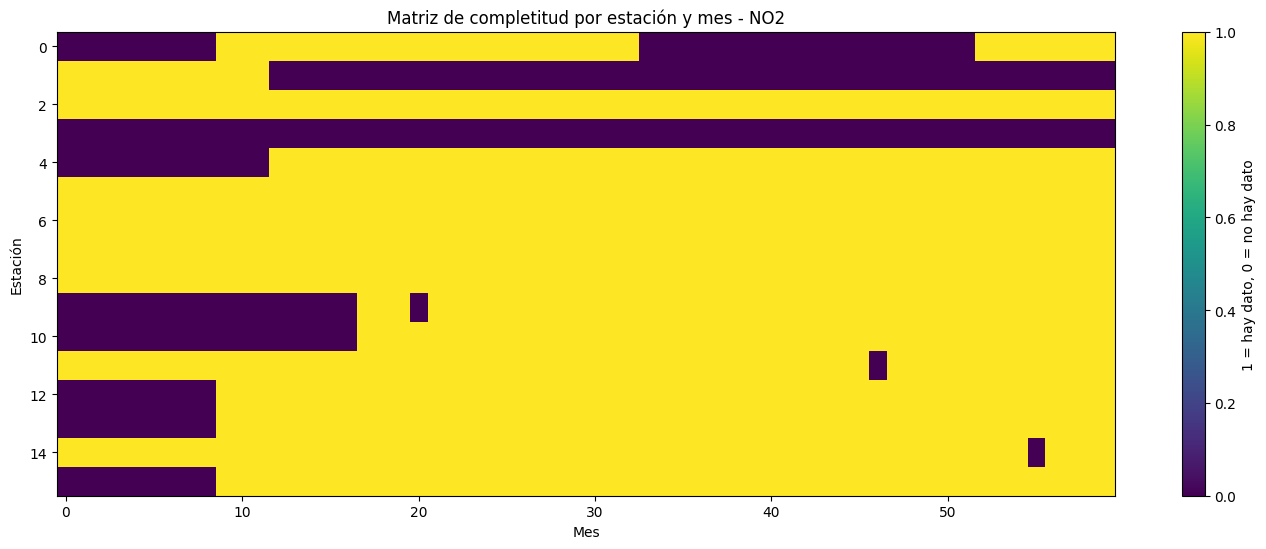

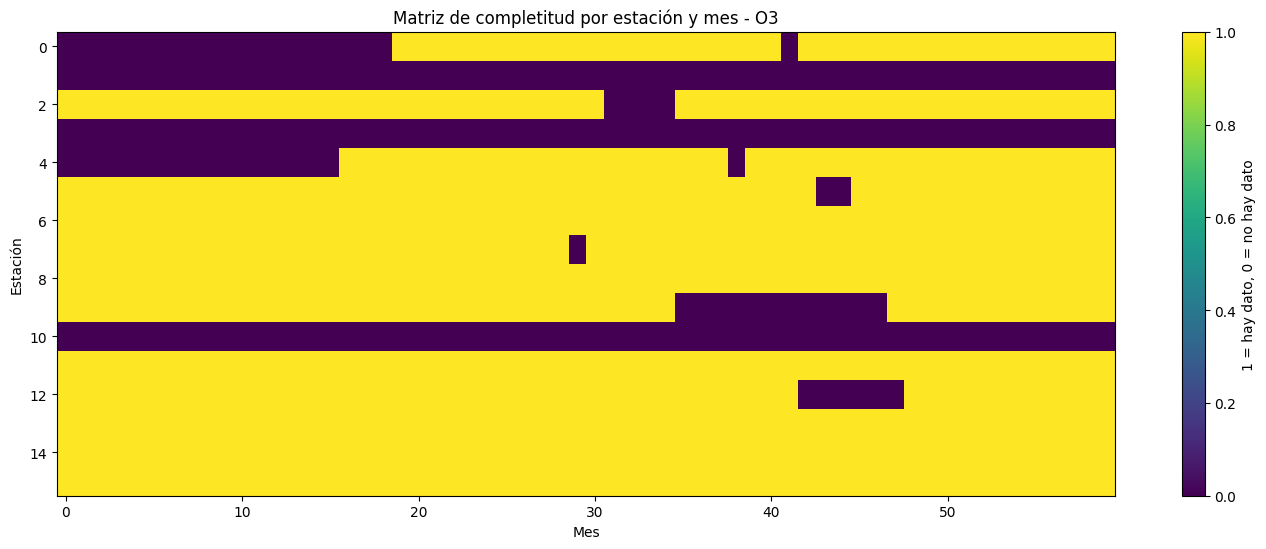

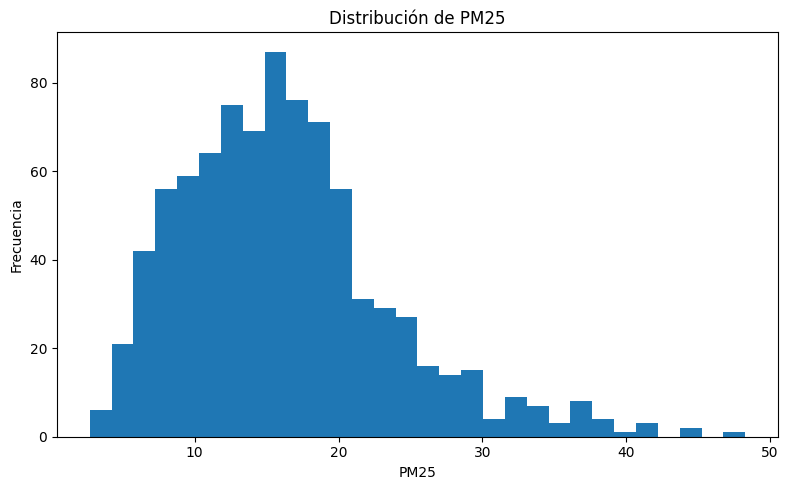

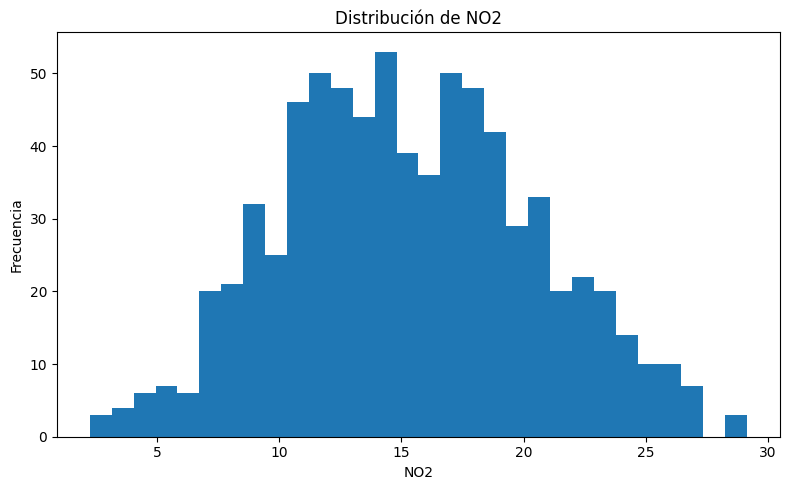

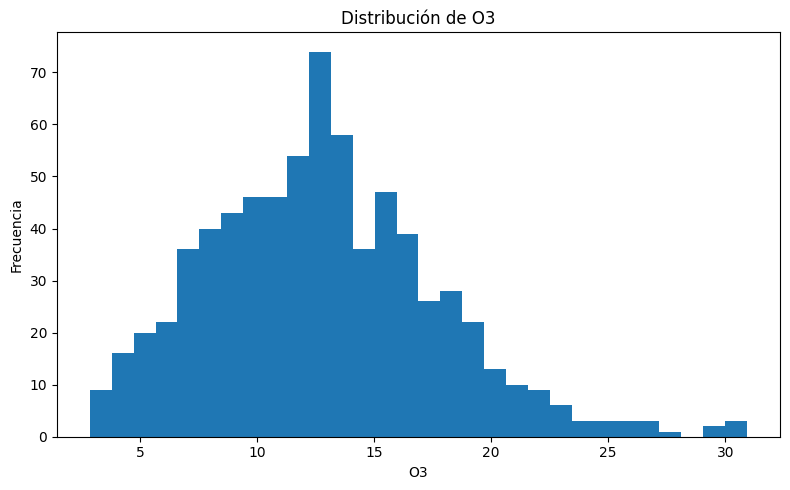

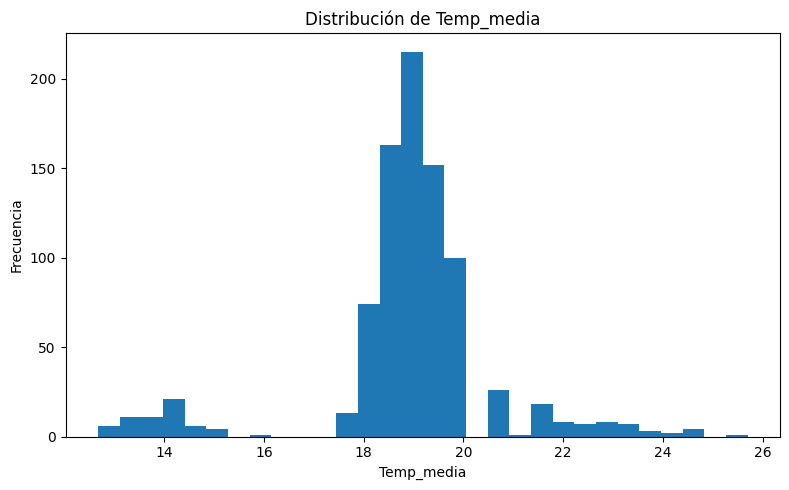

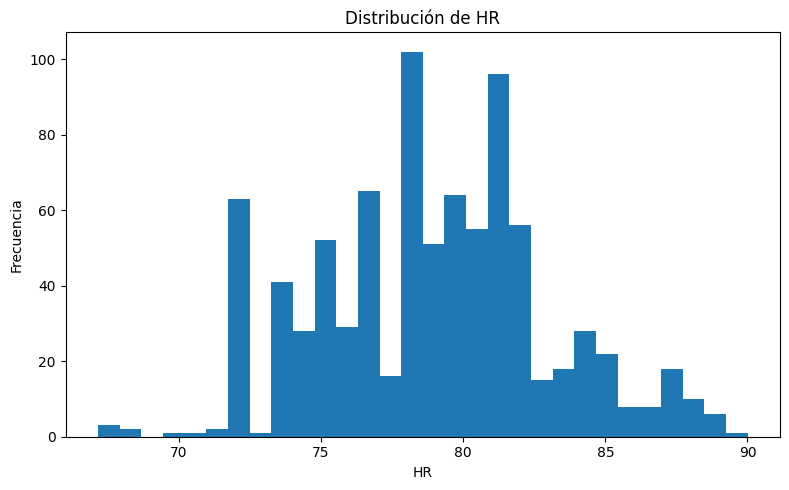

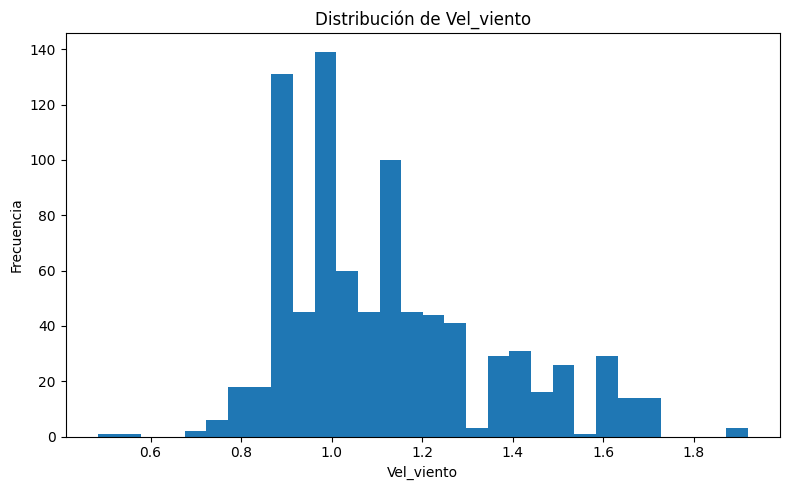

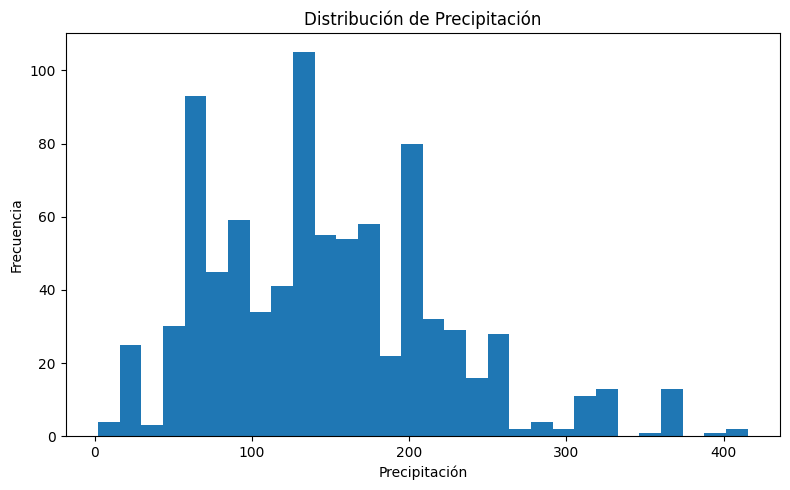

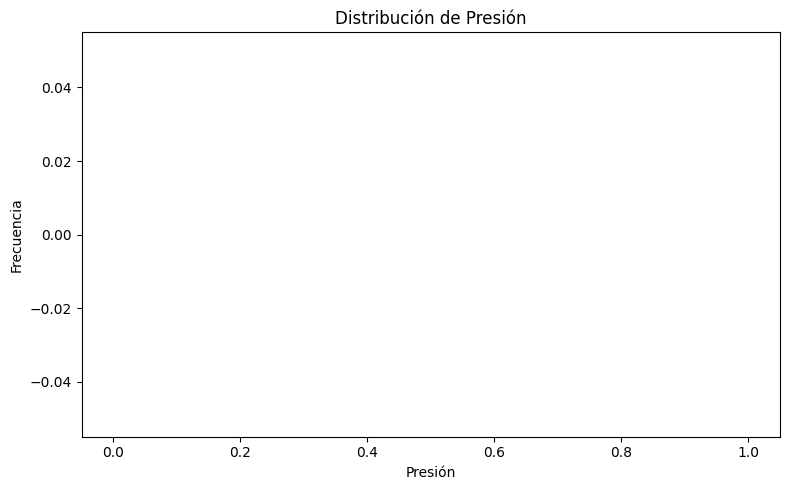


DISPONIBILIDAD ANUAL DE REGISTROS NO NULOS
    Año  PM25  NO2   O3
0  2020   147  108  132
1  2021   174  157  145
2  2022   172  165  150
3  2023   185  155  135
4  2024   178  163  156

RESUMEN BREVE AUTOMÁTICO
El panel contiene 862 registros y 29 variables.
Cubre desde 2020-01-01 hasta 2024-12-01, con 60 meses únicos.
Se identificaron 16 estaciones únicas.
Se identificaron 11 localidades únicas.
PM25: no nulos=856, faltantes=6, % faltante=0.70, media=16.24, min=2.70, max=48.27
NO2: no nulos=748, faltantes=114, % faltante=13.23, media=15.33, min=2.25, max=29.15
O3: no nulos=718, faltantes=144, % faltante=16.71, media=12.78, min=2.86, max=30.94


In [2]:
# ============================================================
# 5.1 - Visualización del panel integrado 2020-2024
# No rehace el procesamiento: SOLO describe y grafica lo que ya existe
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 1) RUTA DEL PANEL FINAL
# ------------------------------------------------------------
PANEL_PATH = r"D:\TRABAJO DE GRADO BEN-MAP\BASES DE DATOS\PANEL AMBIENTAL INTEGRADO\panel_ambiental_mensual_2020_2024.csv"

# ------------------------------------------------------------
# 2) CARGA
# ------------------------------------------------------------
df = pd.read_csv(PANEL_PATH)

print("="*80)
print("DIMENSIONES DEL PANEL")
print("="*80)
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("\nColumnas:")
print(list(df.columns))

# ------------------------------------------------------------
# 3) DETECCIÓN ROBUSTA DE COLUMNAS CLAVE
# ------------------------------------------------------------
def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

col_year = first_existing(["Año", "Anio", "year", "YEAR"], df.columns)
col_month = first_existing(["Mes", "mes", "month", "MONTH"], df.columns)
col_station = first_existing(["Estacion", "ESTACION", "station"], df.columns)
col_localidad = first_existing(["Localidad", "LOCALIDAD", "localidad"], df.columns)

# Coordenadas
col_lat = first_existing(["lat", "LAT", "Latitud", "LATITUD"], df.columns)
col_lon = first_existing(["lon", "LON", "Longitud", "LONGITUD"], df.columns)

# Contaminantes
pollutants = [c for c in ["PM25", "NO2", "O3"] if c in df.columns]

# Flags de validez
valid_flags = [c for c in ["valido_PM25", "valido_NO2", "valido_O3"] if c in df.columns]

# ------------------------------------------------------------
# 4) FECHA MENSUAL
# ------------------------------------------------------------
if col_year is not None and col_month is not None:
    df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
    df[col_month] = pd.to_numeric(df[col_month], errors="coerce")
    df["fecha"] = pd.to_datetime(
        dict(year=df[col_year].astype("Int64"),
             month=df[col_month].astype("Int64"),
             day=1),
        errors="coerce"
    )
else:
    raise ValueError("No encontré columnas de año/mes para construir la fecha.")

print("\n" + "="*80)
print("RANGO TEMPORAL")
print("="*80)
print("Fecha mínima:", df["fecha"].min())
print("Fecha máxima:", df["fecha"].max())
print("Número de meses únicos:", df["fecha"].nunique())

if col_station:
    print("Número de estaciones únicas:", df[col_station].nunique())
if col_localidad:
    print("Número de localidades únicas:", df[col_localidad].nunique())

# ------------------------------------------------------------
# 5) RESUMEN GENERAL DEL PANEL
# ------------------------------------------------------------
print("\n" + "="*80)
print("RESUMEN GENERAL")
print("="*80)

summary_rows = []
for var in pollutants:
    row = {
        "variable": var,
        "no_nulos": int(df[var].notna().sum()),
        "faltantes": int(df[var].isna().sum()),
        "pct_faltante": round(df[var].isna().mean() * 100, 2),
        "media": round(df[var].mean(), 3),
        "mediana": round(df[var].median(), 3),
        "min": round(df[var].min(), 3),
        "max": round(df[var].max(), 3),
        "desv_std": round(df[var].std(), 3),
    }
    # Si hay flag de validez correspondiente
    vf = f"valido_{var}"
    if vf in df.columns:
        row["validos_flag_true"] = int((df[vf] == True).sum())
        row["validos_flag_false"] = int((df[vf] == False).sum())
    summary_rows.append(row)

summary_table = pd.DataFrame(summary_rows)
print(summary_table)

# ------------------------------------------------------------
# 6) PORCENTAJE DE FALTANTES POR VARIABLE
# ------------------------------------------------------------
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
missing_pct = (
    df[numeric_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print("\n" + "="*80)
print("PORCENTAJE DE FALTANTES POR VARIABLE NUMÉRICA")
print("="*80)
print(missing_pct)

plt.figure(figsize=(10, 6))
missing_pct.head(20).sort_values().plot(kind="barh")
plt.title("Porcentaje de faltantes por variable numérica")
plt.xlabel("% de faltantes")
plt.ylabel("Variable")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 7) COBERTURA MENSUAL POR CONTAMINANTE
# ------------------------------------------------------------
if pollutants:
    coverage_monthly = (
        df.groupby("fecha")[pollutants]
        .apply(lambda x: x.notna().sum())
        .reset_index()
    )

    plt.figure(figsize=(12, 6))
    for pol in pollutants:
        plt.plot(coverage_monthly["fecha"], coverage_monthly[pol], marker="o", label=pol)
    plt.title("Cobertura mensual: número de registros no nulos por contaminante")
    plt.xlabel("Fecha")
    plt.ylabel("Número de registros válidos/no nulos")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 8) PROMEDIOS MENSUALES POR CONTAMINANTE
# ------------------------------------------------------------
if pollutants:
    monthly_means = df.groupby("fecha")[pollutants].mean().reset_index()

    plt.figure(figsize=(12, 6))
    for pol in pollutants:
        plt.plot(monthly_means["fecha"], monthly_means[pol], marker="o", label=pol)
    plt.title("Promedio mensual de contaminantes en el panel integrado")
    plt.xlabel("Fecha")
    plt.ylabel("Concentración promedio")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 9) COBERTURA POR ESTACIÓN Y CONTAMINANTE
# ------------------------------------------------------------
if col_station and pollutants:
    for pol in pollutants:
        temp = (
            df.groupby(col_station)[pol]
            .apply(lambda x: x.notna().mean() * 100)
            .sort_values(ascending=True)
        )

        plt.figure(figsize=(10, max(5, len(temp)*0.3)))
        temp.plot(kind="barh")
        plt.title(f"Cobertura porcentual por estación - {pol}")
        plt.xlabel("% de meses con dato")
        plt.ylabel("Estación")
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------
# 10) MATRIZ DE COMPLETITUD MENSUAL
#     (útil para escribir 'calidad y cobertura')
# ------------------------------------------------------------
if col_station and pollutants:
    for pol in pollutants:
        pivot = df.pivot_table(
            index=col_station,
            columns="fecha",
            values=pol,
            aggfunc=lambda x: int(np.any(pd.notna(x)))
        )

        plt.figure(figsize=(14, max(5, len(pivot)*0.35)))
        plt.imshow(pivot.fillna(0), aspect="auto")
        plt.colorbar(label="1 = hay dato, 0 = no hay dato")
        plt.title(f"Matriz de completitud por estación y mes - {pol}")
        plt.xlabel("Mes")
        plt.ylabel("Estación")
        plt.tight_layout()
        plt.show()

# ------------------------------------------------------------
# 11) DISTRIBUCIÓN DE VARIABLES CLAVE
# ------------------------------------------------------------
vars_hist = [v for v in pollutants + ["Temp_media", "HR", "Vel_viento", "Precipitación", "Presión"] if v in df.columns]

for var in vars_hist:
    plt.figure(figsize=(8, 5))
    plt.hist(df[var].dropna(), bins=30)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------
# 12) TABLA DE DISPONIBILIDAD ANUAL
# ------------------------------------------------------------
if col_year and pollutants:
    annual_availability = (
        df.groupby(col_year)[pollutants]
        .apply(lambda x: x.notna().sum())
        .reset_index()
    )

    print("\n" + "="*80)
    print("DISPONIBILIDAD ANUAL DE REGISTROS NO NULOS")
    print("="*80)
    print(annual_availability)

# ------------------------------------------------------------
# 13) RESUMEN PARA PEGAR EN TESIS
# ------------------------------------------------------------
print("\n" + "="*80)
print("RESUMEN BREVE AUTOMÁTICO")
print("="*80)

print(f"El panel contiene {df.shape[0]} registros y {df.shape[1]} variables.")
print(f"Cubre desde {df['fecha'].min().date()} hasta {df['fecha'].max().date()}, con {df['fecha'].nunique()} meses únicos.")

if col_station:
    print(f"Se identificaron {df[col_station].nunique()} estaciones únicas.")
if col_localidad:
    print(f"Se identificaron {df[col_localidad].nunique()} localidades únicas.")

for pol in pollutants:
    print(
        f"{pol}: no nulos={df[pol].notna().sum()}, "
        f"faltantes={df[pol].isna().sum()}, "
        f"% faltante={df[pol].isna().mean()*100:.2f}, "
        f"media={df[pol].mean():.2f}, min={df[pol].min():.2f}, max={df[pol].max():.2f}"
    )

In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# RUTAS
# ============================================================
PANEL_PATH = r"D:\TRABAJO DE GRADO BEN-MAP\BASES DE DATOS\PANEL AMBIENTAL INTEGRADO\panel_ambiental_mensual_2020_2024.csv"
OUTDIR = r"D:\TRABAJO DE GRADO BEN-MAP\IMAGENES"

os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# CARGA DEL PANEL
# ============================================================
df = pd.read_csv(PANEL_PATH)

# ============================================================
# DETECCIÓN DE COLUMNAS
# ============================================================
def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

col_year = first_existing(["Año", "Anio", "year", "YEAR"], df.columns)
col_month = first_existing(["Mes", "mes", "month", "MONTH"], df.columns)
col_station = first_existing(["Estacion", "ESTACION", "station"], df.columns)

pollutants = [c for c in ["PM25", "NO2", "O3"] if c in df.columns]

# ============================================================
# FECHA MENSUAL
# ============================================================
df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
df[col_month] = pd.to_numeric(df[col_month], errors="coerce")

df["fecha"] = pd.to_datetime(
    dict(
        year=df[col_year].astype("Int64"),
        month=df[col_month].astype("Int64"),
        day=1
    ),
    errors="coerce"
)

# ============================================================
# FUNCIÓN PARA GUARDAR FIGURAS
# ============================================================
def guardar_fig(nombre_archivo):
    ruta = os.path.join(OUTDIR, nombre_archivo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"Figura guardada en: {ruta}")
    plt.close()

# ============================================================
# FIGURA 1: PORCENTAJE DE FALTANTES
# ============================================================
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
missing_pct = (
    df[numeric_cols]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

plt.figure(figsize=(10, 6))
missing_pct.head(20).sort_values().plot(kind="barh")
plt.title("Porcentaje de faltantes por variable numérica")
plt.xlabel("% de faltantes")
plt.ylabel("Variable")
guardar_fig("fig_5_1_faltantes_panel.png")

# ============================================================
# FIGURA 2: COBERTURA MENSUAL POR CONTAMINANTE
# ============================================================
coverage_monthly = (
    df.groupby("fecha")[pollutants]
    .apply(lambda x: x.notna().sum())
    .reset_index()
)

plt.figure(figsize=(12, 6))
for pol in pollutants:
    plt.plot(coverage_monthly["fecha"], coverage_monthly[pol], marker="o", label=pol)
plt.title("Cobertura mensual: número de registros no nulos por contaminante")
plt.xlabel("Fecha")
plt.ylabel("Número de registros válidos/no nulos")
plt.legend()
guardar_fig("fig_5_2_cobertura_mensual_contaminantes.png")

# ============================================================
# FIGURA 3: PROMEDIOS MENSUALES POR CONTAMINANTE
# ============================================================
monthly_means = df.groupby("fecha")[pollutants].mean().reset_index()

plt.figure(figsize=(12, 6))
for pol in pollutants:
    plt.plot(monthly_means["fecha"], monthly_means[pol], marker="o", label=pol)
plt.title("Promedio mensual de contaminantes en el panel integrado")
plt.xlabel("Fecha")
plt.ylabel("Concentración promedio")
plt.legend()
guardar_fig("fig_5_3_promedios_mensuales_contaminantes.png")

# ============================================================
# FIGURAS 4, 5 y 6: COBERTURA POR ESTACIÓN
# ============================================================
if col_station:
    nombres = {
        "PM25": "fig_5_4_cobertura_estacion_pm25.png",
        "NO2":  "fig_5_5_cobertura_estacion_no2.png",
        "O3":   "fig_5_6_cobertura_estacion_o3.png",
    }

    for pol in pollutants:
        temp = (
            df.groupby(col_station)[pol]
            .apply(lambda x: x.notna().mean() * 100)
            .sort_values(ascending=True)
        )

        plt.figure(figsize=(10, max(5, len(temp) * 0.3)))
        temp.plot(kind="barh")
        plt.title(f"Cobertura porcentual por estación - {pol}")
        plt.xlabel("% de meses con dato")
        plt.ylabel("Estación")
        guardar_fig(nombres[pol])

# ============================================================
# FIGURAS 7, 8 y 9: MATRICES DE COMPLETITUD
# ============================================================
if col_station:
    nombres_matriz = {
        "PM25": "fig_5_7_matriz_completitud_pm25.png",
        "NO2":  "fig_5_8_matriz_completitud_no2.png",
        "O3":   "fig_5_9_matriz_completitud_o3.png",
    }

    for pol in pollutants:
        pivot = df.pivot_table(
            index=col_station,
            columns="fecha",
            values=pol,
            aggfunc=lambda x: int(np.any(pd.notna(x)))
        )

        plt.figure(figsize=(14, max(5, len(pivot) * 0.35)))
        plt.imshow(pivot.fillna(0), aspect="auto")
        plt.colorbar(label="1 = hay dato, 0 = no hay dato")
        plt.title(f"Matriz de completitud por estación y mes - {pol}")
        plt.xlabel("Mes")
        plt.ylabel("Estación")
        guardar_fig(nombres_matriz[pol])

print("\nExportación finalizada.")

Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_1_faltantes_panel.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_2_cobertura_mensual_contaminantes.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_3_promedios_mensuales_contaminantes.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_4_cobertura_estacion_pm25.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_5_cobertura_estacion_no2.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_6_cobertura_estacion_o3.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_7_matriz_completitud_pm25.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_8_matriz_completitud_no2.png
Figura guardada en: D:\TRABAJO DE GRADO BEN-MAP\IMAGENES\fig_5_9_matriz_completitud_o3.png

Exportación finalizada.


In [6]:
# ============================================================
# RESULTADOS DEL MODELO A-D
# Visualización y exportación de figuras desde el producto final
# ============================================================

import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# RUTAS
# ============================================================
BASE = r"D:\TRABAJO DE GRADO BEN-MAP"
CODIGO_DIR = os.path.join(BASE, "CODIGO")
OUTDIR = os.path.join(BASE, "IMAGENES")

AD_PATH = os.path.join(CODIGO_DIR, "grid_3km_AD_mensual_2020_2024.csv")
W_PATH  = os.path.join(CODIGO_DIR, "W_grid_3km_queen.csv")

os.makedirs(OUTDIR, exist_ok=True)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def guardar_fig(nombre_archivo):
    ruta = os.path.join(OUTDIR, nombre_archivo)
    plt.tight_layout()
    plt.savefig(ruta, dpi=300, bbox_inches="tight")
    print(f"✅ Figura guardada: {ruta}")
    plt.close()

def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

def col_exist(cols, dfcols):
    return [c for c in cols if c in dfcols]

# ============================================================
# 1) CARGA DEL ARCHIVO A-D
# ============================================================
if not os.path.exists(AD_PATH):
    raise FileNotFoundError(f"No encontré el archivo A-D en:\n{AD_PATH}")

df = pd.read_csv(AD_PATH)

# Mostrar columnas para revisar
print("=" * 90)
print("DIMENSIONES DEL ARCHIVO A-D")
print("=" * 90)
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])
print("\nColumnas:")
print(list(df.columns))

# ============================================================
# 2) IDENTIFICAR FECHA
# ============================================================
fecha_col = first_existing(["fecha", "Fecha", "FECHA"], df.columns)

if fecha_col is None:
    # Intenta construirla desde año y mes
    col_year = first_existing(["Año", "Anio", "year", "YEAR"], df.columns)
    col_month = first_existing(["Mes", "mes", "month", "MONTH"], df.columns)

    if col_year is not None and col_month is not None:
        df[col_year] = pd.to_numeric(df[col_year], errors="coerce")
        df[col_month] = pd.to_numeric(df[col_month], errors="coerce")
        df["fecha"] = pd.to_datetime(
            dict(
                year=df[col_year].astype("Int64"),
                month=df[col_month].astype("Int64"),
                day=1
            ),
            errors="coerce"
        )
        fecha_col = "fecha"
    else:
        raise ValueError("No encontré columna fecha ni columnas Año/Mes para construirla.")

df[fecha_col] = pd.to_datetime(df[fecha_col], errors="coerce")

# ============================================================
# 3) IDENTIFICAR VARIABLES DEL MODELO A-D
# ============================================================
idw_cols  = col_exist(["PM25_idw", "NO2_idw", "O3_idw"], df.columns)
diff_cols = col_exist(["diff_PM25_grid", "diff_NO2_grid", "diff_O3_grid"], df.columns)
grad_cols = col_exist(["grad_PM25_grid", "grad_NO2_grid", "grad_O3_grid"], df.columns)
adv_cols  = col_exist(["adv_proxy_PM25_grid", "adv_proxy_NO2_grid", "adv_proxy_O3_grid"], df.columns)
meteo_cols = col_exist(["Vel_viento_idw"], df.columns)

vars_ad = idw_cols + diff_cols + grad_cols + adv_cols + meteo_cols

print("\n" + "=" * 90)
print("VARIABLES A-D ENCONTRADAS")
print("=" * 90)
print("IDW:", idw_cols)
print("Difusión:", diff_cols)
print("Gradiente:", grad_cols)
print("Advección proxy:", adv_cols)
print("Meteorología:", meteo_cols)

print("\n" + "=" * 90)
print("RANGO TEMPORAL")
print("=" * 90)
print("Fecha mínima:", df[fecha_col].min())
print("Fecha máxima:", df[fecha_col].max())
print("Meses únicos:", df[fecha_col].nunique())

if "cell_id" in df.columns:
    print("Celdas únicas:", df["cell_id"].nunique())

# ============================================================
# 4) RESUMEN GENERAL
# ============================================================
summary_rows = []
for var in vars_ad:
    s = pd.to_numeric(df[var], errors="coerce")
    summary_rows.append({
        "variable": var,
        "no_nulos": int(s.notna().sum()),
        "faltantes": int(s.isna().sum()),
        "pct_faltante": round(s.isna().mean() * 100, 2),
        "media": round(s.mean(), 6),
        "mediana": round(s.median(), 6),
        "min": round(s.min(), 6),
        "max": round(s.max(), 6),
        "desv_std": round(s.std(), 6),
    })

summary_ad = pd.DataFrame(summary_rows)

print("\n" + "=" * 90)
print("RESUMEN GENERAL DE VARIABLES A-D")
print("=" * 90)
print(summary_ad)

summary_csv = os.path.join(OUTDIR, "tabla_resumen_AD.csv")
summary_ad.to_csv(summary_csv, index=False)
print(f"\n✅ Tabla guardada: {summary_csv}")

# ============================================================
# 5) FALTANTES
# ============================================================
missing_ad = (
    df[vars_ad]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .mul(100)
    .round(2)
)

print("\n" + "=" * 90)
print("PORCENTAJE DE FALTANTES EN VARIABLES A-D")
print("=" * 90)
print(missing_ad)

plt.figure(figsize=(10, 6))
missing_ad.sort_values().plot(kind="barh")
plt.title("Porcentaje de faltantes en variables del modelo A-D")
plt.xlabel("% de faltantes")
plt.ylabel("Variable")
guardar_fig("fig_5_10_faltantes_variables_AD.png")

# ============================================================
# 6) SERIES MENSUALES DE LOS CAMPOS IDW
# ============================================================
if idw_cols:
    monthly_idw = df.groupby(fecha_col)[idw_cols].mean().reset_index()

    plt.figure(figsize=(12, 6))
    for col in idw_cols:
        plt.plot(monthly_idw[fecha_col], monthly_idw[col], marker="o", label=col.replace("_idw", ""))
    plt.title("Promedio mensual del campo interpolado por contaminante")
    plt.xlabel("Fecha")
    plt.ylabel("Concentración promedio en grilla")
    plt.legend()
    guardar_fig("fig_5_11_series_mensuales_idw.png")

# ============================================================
# 7) SERIES MENSUALES DEL TÉRMINO DIFUSIVO
# ============================================================
if diff_cols:
    monthly_diff = df.groupby(fecha_col)[diff_cols].mean().reset_index()

    plt.figure(figsize=(12, 6))
    for col in diff_cols:
        etiqueta = col.replace("diff_", "").replace("_grid", "")
        plt.plot(monthly_diff[fecha_col], monthly_diff[col], marker="o", label=etiqueta)
    plt.title("Promedio mensual del término difusivo")
    plt.xlabel("Fecha")
    plt.ylabel("Difusión promedio")
    plt.axhline(0, linestyle="--", linewidth=1)
    plt.legend()
    guardar_fig("fig_5_12_series_mensuales_diffusion.png")

# ============================================================
# 8) SERIES MENSUALES DEL GRADIENTE (POR KM)
# ============================================================
if grad_cols:
    monthly_grad = df.groupby(fecha_col)[grad_cols].mean().reset_index().copy()

    grad_km_cols = []
    for col in grad_cols:
        new_col = col.replace("grad_", "grad_km_")
        monthly_grad[new_col] = monthly_grad[col] * 1000.0
        grad_km_cols.append(new_col)

    plt.figure(figsize=(12, 6))
    for col in grad_km_cols:
        etiqueta = col.replace("grad_km_", "").replace("_grid", "")
        plt.plot(monthly_grad[fecha_col], monthly_grad[col], marker="o", label=etiqueta)
    plt.title("Promedio mensual del gradiente espacial (escala por km)")
    plt.xlabel("Fecha")
    plt.ylabel("Gradiente promedio por km")
    plt.legend()
    guardar_fig("fig_5_13_series_mensuales_gradiente_km.png")

# ============================================================
# 9) SERIES MENSUALES DEL PROXY ADVECTIVO
# ============================================================
if adv_cols:
    monthly_adv = df.groupby(fecha_col)[adv_cols].mean().reset_index()

    plt.figure(figsize=(12, 6))
    for col in adv_cols:
        etiqueta = col.replace("adv_proxy_", "").replace("_grid", "")
        plt.plot(monthly_adv[fecha_col], monthly_adv[col], marker="o", label=etiqueta)
    plt.title("Promedio mensual del proxy advectivo")
    plt.xlabel("Fecha")
    plt.ylabel("Advección proxy promedio")
    plt.legend()
    guardar_fig("fig_5_14_series_mensuales_adveccion_proxy.png")

# ============================================================
# 10) HISTOGRAMAS DE VARIABLES A-D
# ============================================================
for var in idw_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[var].dropna(), bins=35)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    guardar_fig(f"hist_{var}.png")

for var in diff_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[var].dropna(), bins=35)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    guardar_fig(f"hist_{var}.png")

for var in grad_cols:
    plt.figure(figsize=(8, 5))
    serie = df[var].dropna() * 1000.0
    plt.hist(serie, bins=35)
    plt.title(f"Distribución de {var} (escala por km)")
    plt.xlabel(f"{var} x 1000")
    plt.ylabel("Frecuencia")
    guardar_fig(f"hist_{var}_km.png")

for var in adv_cols:
    plt.figure(figsize=(8, 5))
    plt.hist(df[var].dropna(), bins=35)
    plt.title(f"Distribución de {var}")
    plt.xlabel(var)
    plt.ylabel("Frecuencia")
    guardar_fig(f"hist_{var}.png")

# ============================================================
# 11) PROMEDIOS POR CELDA
# ============================================================
if "cell_id" in df.columns:
    cell_avg = df.groupby("cell_id")[vars_ad].mean().reset_index()

    for col in grad_cols:
        cell_avg[col.replace("grad_", "grad_km_")] = cell_avg[col] * 1000.0

    cell_avg_csv = os.path.join(OUTDIR, "tabla_promedios_por_celda_AD_2020_2024.csv")
    cell_avg.to_csv(cell_avg_csv, index=False)
    print(f"\n✅ Tabla guardada: {cell_avg_csv}")

# ============================================================
# 12) RESUMEN DE LA MATRIZ DE VECINDAD
# ============================================================
if os.path.exists(W_PATH):
    W = pd.read_csv(W_PATH)

    print("\n" + "=" * 90)
    print("RESUMEN DE LA VECINDAD ESPACIAL W")
    print("=" * 90)
    print("Filas en W:", W.shape[0])
    print("Columnas en W:", W.shape[1])
    print("Columnas W:", list(W.columns))

    c1 = first_existing(["cell_id", "from", "origin", "id"], W.columns)
    c2 = first_existing(["neighbor_id", "to", "neighbor", "id_neighbor"], W.columns)

    if c1 is not None and c2 is not None:
        grados = W.groupby(c1)[c2].nunique()
        print("Número de celdas con vecinas:", grados.shape[0])
        print("Promedio de vecinas por celda:", round(grados.mean(), 3))
        print("Mínimo de vecinas:", int(grados.min()))
        print("Máximo de vecinas:", int(grados.max()))

        grados_desc = grados.describe()
        print("\nResumen descriptivo del número de vecinas:")
        print(grados_desc)

        plt.figure(figsize=(8, 5))
        plt.hist(grados, bins=20)
        plt.title("Distribución del número de vecinas por celda")
        plt.xlabel("Número de vecinas")
        plt.ylabel("Frecuencia")
        guardar_fig("fig_5_15_distribucion_vecinas_por_celda.png")
else:
    print(f"\n⚠️ No encontré W en: {W_PATH}")

# ============================================================
# 13) RESUMEN BREVE AUTOMÁTICO
# ============================================================
print("\n" + "=" * 90)
print("RESUMEN BREVE AUTOMÁTICO A-D")
print("=" * 90)

print(f"El archivo A-D contiene {df.shape[0]} registros y {df.shape[1]} variables.")
print(f"Cubre desde {df[fecha_col].min().date()} hasta {df[fecha_col].max().date()}, con {df[fecha_col].nunique()} meses únicos.")

if "cell_id" in df.columns:
    print(f"Se identificaron {df['cell_id'].nunique()} celdas únicas en la grilla.")

for var in idw_cols:
    s = df[var]
    print(
        f"{var}: no nulos={s.notna().sum()}, faltantes={s.isna().sum()}, "
        f"% faltante={s.isna().mean()*100:.2f}, media={s.mean():.4f}, "
        f"min={s.min():.4f}, max={s.max():.4f}"
    )

for var in diff_cols + grad_cols + adv_cols:
    s = df[var]
    print(
        f"{var}: no nulos={s.notna().sum()}, faltantes={s.isna().sum()}, "
        f"% faltante={s.isna().mean()*100:.2f}, media={s.mean():.6f}, "
        f"min={s.min():.6f}, max={s.max():.6f}"
    )

print("\n✅ Proceso terminado.")
print("Muéstrame estas salidas:")
print("1) tabla_resumen_AD.csv")
print("2) fig_5_10_faltantes_variables_AD.png")
print("3) fig_5_11_series_mensuales_idw.png")
print("4) fig_5_12_series_mensuales_diffusion.png")
print("5) fig_5_13_series_mensuales_gradiente_km.png")
print("6) fig_5_14_series_mensuales_adveccion_proxy.png")
print("7) fig_5_15_distribucion_vecinas_por_celda.png")
print("8) el bloque RESUMEN BREVE AUTOMÁTICO A-D")

DIMENSIONES DEL ARCHIVO A-D
Filas: 15240
Columnas: 15

Columnas:
['cell_id', 'fecha', 'PM25_idw', 'NO2_idw', 'O3_idw', 'Vel_viento_idw', 'diff_PM25_grid', 'grad_PM25_grid', 'adv_proxy_PM25_grid', 'diff_NO2_grid', 'grad_NO2_grid', 'adv_proxy_NO2_grid', 'diff_O3_grid', 'grad_O3_grid', 'adv_proxy_O3_grid']

VARIABLES A-D ENCONTRADAS
IDW: ['PM25_idw', 'NO2_idw', 'O3_idw']
Difusión: ['diff_PM25_grid', 'diff_NO2_grid', 'diff_O3_grid']
Gradiente: ['grad_PM25_grid', 'grad_NO2_grid', 'grad_O3_grid']
Advección proxy: ['adv_proxy_PM25_grid', 'adv_proxy_NO2_grid', 'adv_proxy_O3_grid']
Meteorología: ['Vel_viento_idw']

RANGO TEMPORAL
Fecha mínima: 2020-01-01 00:00:00
Fecha máxima: 2024-12-01 00:00:00
Meses únicos: 60
Celdas únicas: 254

RESUMEN GENERAL DE VARIABLES A-D
               variable  no_nulos  faltantes  pct_faltante      media  \
0              PM25_idw     15240          0           0.0  16.612188   
1               NO2_idw     15240          0           0.0  15.161641   
2             

# resultados para hbm


In [2]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Mapas opcionales
TRY_MAPS = True
try:
    import geopandas as gpd
except Exception:
    TRY_MAPS = False

# ============================================================
# CONFIGURACIÓN
# ============================================================
BASE = r"D:\TRABAJO DE GRADO BEN-MAP"
CODIGO_DIR = os.path.join(BASE, "CODIGO")
OUTDIR = os.path.join(BASE, "IMAGENES")

TAG = "PM25"          # Cambia a "NO2" o "O3"
MODEL = "M1bclean"

HBM_DIR = os.path.join(CODIGO_DIR, f"HBM_{TAG}_V2_OUT")
os.makedirs(OUTDIR, exist_ok=True)

GRID_CANDIDATES = [
    os.path.join(BASE, "BASES DE DATOS", "PANEL AMBIENTAL INTEGRADO", "grid_3km.geojson"),
    os.path.join(BASE, "BASES DE DATOS", "PANEL AMBIENTAL INTEGRADO", "grid_3km.shp"),
    os.path.join(BASE, "BASES DE DATOS", "PANEL AMBIENTAL INTEGRADO", "grid_3km.gpkg"),
    os.path.join(CODIGO_DIR, "grid_3km.geojson"),
    os.path.join(CODIGO_DIR, "grid_3km.shp"),
    os.path.join(CODIGO_DIR, "grid_3km.gpkg"),
]

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def savefig(name):
    path = os.path.join(OUTDIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"✅ Figura guardada: {path}")
    plt.close()

def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

def find_cols_by_keywords(columns, include=None, exclude=None):
    include = include or []
    exclude = exclude or []
    out = []
    for c in columns:
        cl = c.lower()
        if all(k in cl for k in include) and not any(k in cl for k in exclude):
            out.append(c)
    return out

def best_match(columns, include_options, exclude_options=None):
    exclude_options = exclude_options or []
    for keys in include_options:
        matches = find_cols_by_keywords(columns, include=keys, exclude=exclude_options)
        if matches:
            return matches[0]
    return None

def safe_read_csv(path):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Archivo leído: {path}")
        print(f"   Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
        return df
    else:
        print(f"⚠️ No encontrado: {path}")
        return None

def find_grid():
    for p in GRID_CANDIDATES:
        if os.path.exists(p):
            return p
    return None

# ============================================================
# ARCHIVOS
# ============================================================
paths = {
    "audit_flag": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_audit_flag_summary.csv"),
    "audit_station": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_audit_station_summary.csv"),
    "obs_panel_clean": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_panel_clean_v1.csv"),
    "obs_panel_v2": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_panel_v2.csv"),
    "metrics_folds": os.path.join(HBM_DIR, f"HBM_{TAG}_{MODEL}_metrics_folds.csv"),
    "pred_test": os.path.join(HBM_DIR, f"HBM_{TAG}_{MODEL}_pred_test_all_folds.csv"),
    "surface_final": os.path.join(HBM_DIR, f"HBM_{TAG}_{MODEL}_surface_final.csv"),
    "w_edges": os.path.join(HBM_DIR, f"HBM_{TAG}_W_edges_queen_v2.csv"),
}

# ============================================================
# 1) CARGA
# ============================================================
audit_flag = safe_read_csv(paths["audit_flag"])
audit_station = safe_read_csv(paths["audit_station"])
obs_panel_clean = safe_read_csv(paths["obs_panel_clean"])
obs_panel_v2 = safe_read_csv(paths["obs_panel_v2"])
metrics_folds = safe_read_csv(paths["metrics_folds"])
pred_test = safe_read_csv(paths["pred_test"])
surface_final = safe_read_csv(paths["surface_final"])
w_edges = safe_read_csv(paths["w_edges"])

print("\n" + "="*100)
print(f"RESULTADOS HBM - {TAG}")
print("="*100)

# ============================================================
# 2) AUDITORÍA DE OBSERVACIONES
# ============================================================
if audit_flag is not None:
    print("\n--- Columnas audit_flag ---")
    print(list(audit_flag.columns))

    cat_col = None
    num_col = None

    for c in audit_flag.columns:
        if audit_flag[c].dtype == "object":
            cat_col = c
            break

    num_candidates = audit_flag.select_dtypes(include=[np.number]).columns.tolist()
    if num_candidates:
        num_col = first_existing(
            ["n", "count", "n_rows", "rows", "casos", "frecuencia", "pct", "porcentaje"],
            num_candidates
        )
        if num_col is None:
            num_col = num_candidates[0]

    if cat_col is not None and num_col is not None:
        temp = audit_flag[[cat_col, num_col]].dropna().sort_values(num_col, ascending=True)
        plt.figure(figsize=(10, 6))
        plt.barh(temp[cat_col].astype(str), temp[num_col])
        plt.title(f"Resumen de auditoría de observaciones - {TAG}")
        plt.xlabel(num_col)
        plt.ylabel(cat_col)
        savefig(f"fig_5_16_auditoria_flags_{TAG.lower()}.png")

# ============================================================
# 3) RESUMEN POR ESTACIÓN
# ============================================================
if audit_station is not None:
    print("\n--- Columnas audit_station ---")
    print(list(audit_station.columns))

    station_col = best_match(
        audit_station.columns,
        include_options=[["station"], ["estacion"], ["site"]]
    )

    num_cols_station = audit_station.select_dtypes(include=[np.number]).columns.tolist()

    if station_col is not None and len(num_cols_station) > 0:
        value_col = first_existing(
            ["n_obs", "n", "count", "pct", "coverage", "n_valid", "valid_obs"],
            num_cols_station
        )
        if value_col is None:
            value_col = num_cols_station[0]

        temp = audit_station[[station_col, value_col]].dropna().sort_values(value_col, ascending=True)

        plt.figure(figsize=(10, max(5, len(temp) * 0.35)))
        plt.barh(temp[station_col].astype(str), temp[value_col])
        plt.title(f"Resumen por estación para el HBM - {TAG}")
        plt.xlabel(value_col)
        plt.ylabel("Estación")
        savefig(f"fig_5_17_resumen_estaciones_hbm_{TAG.lower()}.png")

# ============================================================
# 4) PANEL OBSERVADO FINAL: RESUMEN BÁSICO
# ============================================================
panel_ref = obs_panel_v2 if obs_panel_v2 is not None else obs_panel_clean

if panel_ref is not None:
    print("\n--- Columnas panel observado ---")
    print(list(panel_ref.columns))

    fecha_col = best_match(
        panel_ref.columns,
        include_options=[["fecha"], ["date"], ["month"], ["mes"], ["time"]]
    )
    station_col = best_match(
        panel_ref.columns,
        include_options=[["station"], ["estacion"], ["site"]]
    )

    print("\nRESUMEN PANEL OBSERVADO")
    print(f"Filas: {panel_ref.shape[0]}")
    print(f"Columnas: {panel_ref.shape[1]}")
    if fecha_col is not None:
        panel_ref[fecha_col] = pd.to_datetime(panel_ref[fecha_col], errors="coerce")
        print(f"Fecha mínima: {panel_ref[fecha_col].min()}")
        print(f"Fecha máxima: {panel_ref[fecha_col].max()}")
        print(f"Meses únicos: {panel_ref[fecha_col].nunique()}")
    if station_col is not None:
        print(f"Estaciones únicas: {panel_ref[station_col].nunique()}")

# ============================================================
# 5) MÉTRICAS POR FOLDS
# ============================================================
if metrics_folds is not None:
    print("\n--- Columnas metrics_folds ---")
    print(list(metrics_folds.columns))

    num_cols = metrics_folds.select_dtypes(include=[np.number]).columns.tolist()
    fold_col = best_match(metrics_folds.columns, include_options=[["fold"]])

    if fold_col in num_cols:
        num_cols.remove(fold_col)

    if len(num_cols) > 0:
        metrics_summary = metrics_folds[num_cols].agg(["mean", "std", "min", "max"]).T.reset_index()
        metrics_summary.columns = ["metrica", "media", "desv_std", "min", "max"]

        out_metrics = os.path.join(OUTDIR, f"tabla_5_3_metricas_{TAG.lower()}_summary.csv")
        metrics_summary.to_csv(out_metrics, index=False)
        print(f"✅ Tabla guardada: {out_metrics}")
        print(metrics_summary)

        plt.figure(figsize=(10, 6))
        plt.bar(metrics_summary["metrica"], metrics_summary["media"])
        plt.title(f"Métricas promedio por folds - HBM {TAG}")
        plt.xlabel("Métrica")
        plt.ylabel("Valor promedio")
        plt.xticks(rotation=45, ha="right")
        savefig(f"fig_5_18_metricas_promedio_folds_{TAG.lower()}.png")

# ============================================================
# 6) PREDICCIONES: OBSERVADO VS PREDICHO
# ============================================================
if pred_test is not None:
    print("\n--- Columnas pred_test ---")
    print(list(pred_test.columns))

    fecha_col = best_match(
        pred_test.columns,
        include_options=[["fecha"], ["date"], ["month"], ["mes"], ["time"]]
    )
    fold_col = best_match(
        pred_test.columns,
        include_options=[["fold"]]
    )

    obs_col = best_match(
        pred_test.columns,
        include_options=[["observed"], ["obs"], ["y_true"], ["y_obs"], ["actual"]],
        exclude_options=["pred", "resid", "sd", "lower", "upper", "p05", "p50", "p95"]
    )

    if obs_col is None:
        obs_col = best_match(
            pred_test.columns,
            include_options=[[TAG.lower()]],
            exclude_options=["pred", "resid", "sd", "lower", "upper", "p05", "p50", "p95", "cell", "id"]
        )

    pred_col = best_match(
        pred_test.columns,
        include_options=[["pred_mean"], ["y_pred"], ["pred"], ["mu"], ["yhat"], ["p50"]],
        exclude_options=["resid", "sd", "lower", "upper", "p05", "p95", "width"]
    )

    if obs_col is not None and pred_col is not None:
        pred_test[obs_col] = pd.to_numeric(pred_test[obs_col], errors="coerce")
        pred_test[pred_col] = pd.to_numeric(pred_test[pred_col], errors="coerce")
        pred_test["residuo"] = pred_test[obs_col] - pred_test[pred_col]

        plt.figure(figsize=(7, 7))
        plt.scatter(pred_test[obs_col], pred_test[pred_col], alpha=0.5)
        mn = np.nanmin([pred_test[obs_col].min(), pred_test[pred_col].min()])
        mx = np.nanmax([pred_test[obs_col].max(), pred_test[pred_col].max()])
        plt.plot([mn, mx], [mn, mx], linestyle="--")
        plt.title(f"Observado vs predicho - HBM {TAG}")
        plt.xlabel("Observado")
        plt.ylabel("Predicho")
        savefig(f"fig_5_19_obs_vs_pred_{TAG.lower()}.png")

        plt.figure(figsize=(8, 5))
        plt.hist(pred_test["residuo"].dropna(), bins=35)
        plt.title(f"Distribución de residuos - HBM {TAG}")
        plt.xlabel("Residuo (observado - predicho)")
        plt.ylabel("Frecuencia")
        savefig(f"fig_5_20_residuos_{TAG.lower()}.png")

        if fecha_col is not None:
            pred_test[fecha_col] = pd.to_datetime(pred_test[fecha_col], errors="coerce")
            monthly = pred_test.groupby(fecha_col)[[obs_col, pred_col]].mean().reset_index()

            plt.figure(figsize=(12, 6))
            plt.plot(monthly[fecha_col], monthly[obs_col], marker="o", label="Observado")
            plt.plot(monthly[fecha_col], monthly[pred_col], marker="o", label="Predicho")
            plt.title(f"Serie mensual observado vs predicho - HBM {TAG}")
            plt.xlabel("Fecha")
            plt.ylabel(TAG)
            plt.legend()
            savefig(f"fig_5_21_serie_obs_vs_pred_{TAG.lower()}.png")

        if fold_col is not None:
            plt.figure(figsize=(8, 5))
            pred_test.boxplot(column="residuo", by=fold_col)
            plt.suptitle("")
            plt.title(f"Residuos por fold - HBM {TAG}")
            plt.xlabel("Fold")
            plt.ylabel("Residuo")
            savefig(f"fig_5_22_residuos_por_fold_{TAG.lower()}.png")
    else:
        print("⚠️ No pude identificar correctamente las columnas de observado y predicho en pred_test.")

# ============================================================
# 7) SUPERFICIE FINAL E INCERTIDUMBRE
# ============================================================
if surface_final is not None:
    print("\n--- Columnas surface_final ---")
    print(list(surface_final.columns))

    cell_col = best_match(
        surface_final.columns,
        include_options=[["cell_id"], ["cell"], ["id"]]
    )
    fecha_col = best_match(
        surface_final.columns,
        include_options=[["fecha"], ["date"], ["month"], ["mes"], ["time"]]
    )

    p05_col = best_match(
        surface_final.columns,
        include_options=[["p05"], ["q05"], ["lower"], ["lwr"]]
    )
    p50_col = best_match(
        surface_final.columns,
        include_options=[["p50"], ["q50"], ["median"], ["mean"], ["mu"]]
    )
    p95_col = best_match(
        surface_final.columns,
        include_options=[["p95"], ["q95"], ["upper"], ["upr"]]
    )

    if p50_col is not None:
        surface_final[p50_col] = pd.to_numeric(surface_final[p50_col], errors="coerce")
    if p05_col is not None:
        surface_final[p05_col] = pd.to_numeric(surface_final[p05_col], errors="coerce")
    if p95_col is not None:
        surface_final[p95_col] = pd.to_numeric(surface_final[p95_col], errors="coerce")

    if fecha_col is not None and p50_col is not None:
        surface_final[fecha_col] = pd.to_datetime(surface_final[fecha_col], errors="coerce")
        s_month = surface_final.groupby(fecha_col)[p50_col].mean().reset_index()

        plt.figure(figsize=(12, 6))
        plt.plot(s_month[fecha_col], s_month[p50_col], marker="o")
        plt.title(f"Promedio mensual de la superficie posterior central - HBM {TAG}")
        plt.xlabel("Fecha")
        plt.ylabel(f"{TAG} (P50 o media posterior)")
        savefig(f"fig_5_23_superficie_central_mensual_{TAG.lower()}.png")

    if fecha_col is not None and p05_col is not None and p95_col is not None:
        surface_final["ancho_ic90"] = surface_final[p95_col] - surface_final[p05_col]
        s_unc = surface_final.groupby(fecha_col)["ancho_ic90"].mean().reset_index()

        plt.figure(figsize=(12, 6))
        plt.plot(s_unc[fecha_col], s_unc["ancho_ic90"], marker="o")
        plt.title(f"Promedio mensual del ancho del intervalo creíble - HBM {TAG}")
        plt.xlabel("Fecha")
        plt.ylabel("P95 - P05")
        savefig(f"fig_5_24_ancho_intervalo_mensual_{TAG.lower()}.png")

    grid_path = find_grid()
    if TRY_MAPS and grid_path is not None and cell_col is not None and p50_col is not None:
        print(f"✅ Grilla encontrada para mapas: {grid_path}")
        grid = gpd.read_file(grid_path)

        if "cell_id" in grid.columns:
            grid["cell_id"] = grid["cell_id"].astype(str)
            surface_final[cell_col] = surface_final[cell_col].astype(str)

            agg_cols = [p50_col]
            if p05_col is not None and p95_col is not None:
                surface_final["ancho_ic90"] = surface_final[p95_col] - surface_final[p05_col]
                agg_cols.append("ancho_ic90")

            map_df = surface_final.groupby(cell_col)[agg_cols].mean().reset_index()
            gmap = grid.merge(map_df, left_on="cell_id", right_on=cell_col, how="left")

            plt.figure(figsize=(8, 8))
            gmap.plot(column=p50_col, legend=True, missing_kwds={"color": "lightgrey"})
            plt.title(f"Superficie posterior central promedio 2020-2024 - HBM {TAG}")
            plt.axis("off")
            savefig(f"fig_5_25_mapa_superficie_central_{TAG.lower()}.png")

            if "ancho_ic90" in gmap.columns:
                plt.figure(figsize=(8, 8))
                gmap.plot(column="ancho_ic90", legend=True, missing_kwds={"color": "lightgrey"})
                plt.title(f"Ancho del intervalo creíble promedio 2020-2024 - HBM {TAG}")
                plt.axis("off")
                savefig(f"fig_5_26_mapa_incertidumbre_{TAG.lower()}.png")
        else:
            print("⚠️ La grilla encontrada no tiene columna cell_id. No se hicieron mapas.")

# ============================================================
# 8) TABLAS DE SALIDA
# ============================================================
if audit_station is not None:
    out_station = os.path.join(OUTDIR, f"tabla_5_3_station_summary_{TAG.lower()}.csv")
    audit_station.to_csv(out_station, index=False)
    print(f"✅ Tabla guardada: {out_station}")

if surface_final is not None:
    out_surface = os.path.join(OUTDIR, f"tabla_5_3_surface_final_{TAG.lower()}.csv")
    surface_final.to_csv(out_surface, index=False)
    print(f"✅ Tabla guardada: {out_surface}")

# ============================================================
# 9) RESUMEN AUTOMÁTICO
# ============================================================
print("\n" + "="*100)
print(f"RESUMEN BREVE AUTOMÁTICO HBM - {TAG}")
print("="*100)

if panel_ref is not None:
    print(f"Panel observado usado por el HBM: {panel_ref.shape[0]} registros y {panel_ref.shape[1]} variables.")

if metrics_folds is not None:
    num_cols = metrics_folds.select_dtypes(include=[np.number]).columns.tolist()
    fold_col = best_match(metrics_folds.columns, include_options=[["fold"]])
    if fold_col in num_cols:
        num_cols.remove(fold_col)
    if len(num_cols) > 0:
        for c in num_cols:
            print(f"{c}: media={metrics_folds[c].mean():.6f}, min={metrics_folds[c].min():.6f}, max={metrics_folds[c].max():.6f}")

if pred_test is not None:
    obs_col = best_match(
        pred_test.columns,
        include_options=[["observed"], ["obs"], ["y_true"], ["y_obs"], ["actual"]],
        exclude_options=["pred", "resid", "sd", "lower", "upper", "p05", "p50", "p95"]
    )
    if obs_col is None:
        obs_col = best_match(
            pred_test.columns,
            include_options=[[TAG.lower()]],
            exclude_options=["pred", "resid", "sd", "lower", "upper", "p05", "p50", "p95", "cell", "id"]
        )

    pred_col = best_match(
        pred_test.columns,
        include_options=[["pred_mean"], ["y_pred"], ["pred"], ["mu"], ["yhat"], ["p50"]],
        exclude_options=["resid", "sd", "lower", "upper", "p05", "p95", "width"]
    )
    if obs_col is not None and pred_col is not None:
        pred_test[obs_col] = pd.to_numeric(pred_test[obs_col], errors="coerce")
        pred_test[pred_col] = pd.to_numeric(pred_test[pred_col], errors="coerce")
        resid = pred_test[obs_col] - pred_test[pred_col]
        print(f"Residuo medio: {resid.mean():.6f}")
        print(f"Residuo std: {resid.std():.6f}")

if surface_final is not None:
    p50_col = best_match(
        surface_final.columns,
        include_options=[["p50"], ["q50"], ["median"], ["mean"], ["mu"]]
    )
    p05_col = best_match(
        surface_final.columns,
        include_options=[["p05"], ["q05"], ["lower"], ["lwr"]]
    )
    p95_col = best_match(
        surface_final.columns,
        include_options=[["p95"], ["q95"], ["upper"], ["upr"]]
    )
    if p50_col is not None:
        print(f"Superficie central promedio: {pd.to_numeric(surface_final[p50_col], errors='coerce').mean():.6f}")
    if p05_col is not None and p95_col is not None:
        ancho = pd.to_numeric(surface_final[p95_col], errors='coerce') - pd.to_numeric(surface_final[p05_col], errors='coerce')
        print(f"Ancho promedio del intervalo creíble: {ancho.mean():.6f}")

print("\n✅ Proceso terminado.")
print("Muéstrame después estas figuras:")
print("1) fig_5_18_metricas_promedio_folds_*.png")
print("2) fig_5_19_obs_vs_pred_*.png")
print("3) fig_5_20_residuos_*.png")
print("4) fig_5_21_serie_obs_vs_pred_*.png")
print("5) fig_5_23_superficie_central_mensual_*.png")
print("6) fig_5_24_ancho_intervalo_mensual_*.png")
print("7) y el bloque RESUMEN BREVE AUTOMÁTICO HBM")

✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_obs_audit_flag_summary.csv
   Filas: 16 | Columnas: 10
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_obs_audit_station_summary.csv
   Filas: 16 | Columnas: 13
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_obs_panel_clean_v1.csv
   Filas: 808 | Columnas: 44
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_obs_panel_v2.csv
   Filas: 808 | Columnas: 45
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1bclean_metrics_folds.csv
   Filas: 3 | Columnas: 13
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1bclean_pred_test_all_folds.csv
   Filas: 510 | Columnas: 13
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25_M1bclean_surface_final.csv
   Filas: 15240 | Columnas: 10
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_PM25_V2_OUT\HBM_PM25

<Figure size 800x500 with 0 Axes>

In [5]:
import os
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# CONFIGURACIÓN
# ============================================================
BASE = r"D:\TRABAJO DE GRADO BEN-MAP"
CODIGO_DIR = os.path.join(BASE, "CODIGO")

TAG = "O3"          # Cambia a "NO2" o "O3"
MODEL = "M1bclean"

HBM_DIR = os.path.join(CODIGO_DIR, f"HBM_{TAG}_V2_OUT")

# Carpeta principal de resultados
RESULTADOS_DIR = os.path.join(BASE, "RESULTADOS_HBM")
RESULTADOS_TAG_DIR = os.path.join(RESULTADOS_DIR, TAG)

os.makedirs(RESULTADOS_DIR, exist_ok=True)
os.makedirs(RESULTADOS_TAG_DIR, exist_ok=True)

# ============================================================
# FUNCIONES AUXILIARES
# ============================================================
def savefig(name):
    path = os.path.join(RESULTADOS_TAG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"✅ Figura guardada: {path}")
    plt.close()

def savecsv(df, name):
    path = os.path.join(RESULTADOS_TAG_DIR, name)
    df.to_csv(path, index=False)
    print(f"✅ Tabla guardada: {path}")

def first_existing(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

def find_cols_by_keywords(columns, include=None, exclude=None):
    include = include or []
    exclude = exclude or []
    out = []
    for c in columns:
        cl = c.lower()
        if all(k in cl for k in include) and not any(k in cl for k in exclude):
            out.append(c)
    return out

def best_match(columns, include_options, exclude_options=None):
    exclude_options = exclude_options or []
    for keys in include_options:
        matches = find_cols_by_keywords(columns, include=keys, exclude=exclude_options)
        if matches:
            return matches[0]
    return None

def safe_read_csv(path):
    if os.path.exists(path):
        df = pd.read_csv(path)
        print(f"✅ Archivo leído: {path}")
        print(f"   Filas: {df.shape[0]} | Columnas: {df.shape[1]}")
        return df
    else:
        print(f"⚠️ No encontrado: {path}")
        return None

# ============================================================
# ARCHIVOS
# ============================================================
paths = {
    "audit_flag": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_audit_flag_summary.csv"),
    "audit_station": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_audit_station_summary.csv"),
    "obs_panel_clean": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_panel_clean_v1.csv"),
    "obs_panel_v2": os.path.join(HBM_DIR, f"HBM_{TAG}_obs_panel_v2.csv"),
    "metrics_folds": os.path.join(HBM_DIR, f"HBM_{TAG}_{MODEL}_metrics_folds.csv"),
    "pred_test": os.path.join(HBM_DIR, f"HBM_{TAG}_{MODEL}_pred_test_all_folds.csv"),
    "surface_final": os.path.join(HBM_DIR, f"HBM_{TAG}_{MODEL}_surface_final.csv"),
    "w_edges": os.path.join(HBM_DIR, f"HBM_{TAG}_W_edges_queen_v2.csv"),
}

# ============================================================
# 1) CARGA
# ============================================================
audit_flag = safe_read_csv(paths["audit_flag"])
audit_station = safe_read_csv(paths["audit_station"])
obs_panel_clean = safe_read_csv(paths["obs_panel_clean"])
obs_panel_v2 = safe_read_csv(paths["obs_panel_v2"])
metrics_folds = safe_read_csv(paths["metrics_folds"])
pred_test = safe_read_csv(paths["pred_test"])
surface_final = safe_read_csv(paths["surface_final"])
w_edges = safe_read_csv(paths["w_edges"])

print("\n" + "="*100)
print(f"RESULTADOS HBM - {TAG}")
print("="*100)

# ============================================================
# 2) AUDITORÍA DE OBSERVACIONES
# ============================================================
if audit_flag is not None:
    print("\n--- Columnas audit_flag ---")
    print(list(audit_flag.columns))
    savecsv(audit_flag, f"tabla_auditoria_flags_{TAG.lower()}.csv")

    cat_col = None
    num_col = None

    for c in audit_flag.columns:
        if audit_flag[c].dtype == "object":
            cat_col = c
            break

    num_candidates = audit_flag.select_dtypes(include=[np.number]).columns.tolist()
    if num_candidates:
        num_col = first_existing(
            ["n", "count", "n_rows", "rows", "casos", "frecuencia", "pct", "porcentaje"],
            num_candidates
        )
        if num_col is None:
            num_col = num_candidates[0]

    if cat_col is not None and num_col is not None:
        temp = audit_flag[[cat_col, num_col]].dropna().sort_values(num_col, ascending=True)
        plt.figure(figsize=(10, 6))
        plt.barh(temp[cat_col].astype(str), temp[num_col])
        plt.title(f"Resumen de auditoría de observaciones - HBM {TAG}")
        plt.xlabel(num_col)
        plt.ylabel(cat_col)
        savefig(f"fig_hbm_auditoria_flags_{TAG.lower()}.png")

# ============================================================
# 3) RESUMEN POR ESTACIÓN
# ============================================================
if audit_station is not None:
    print("\n--- Columnas audit_station ---")
    print(list(audit_station.columns))
    savecsv(audit_station, f"tabla_resumen_estaciones_{TAG.lower()}.csv")

    station_col = best_match(
        audit_station.columns,
        include_options=[["station"], ["estacion"], ["site"]]
    )

    num_cols_station = audit_station.select_dtypes(include=[np.number]).columns.tolist()

    if station_col is not None and len(num_cols_station) > 0:
        value_col = first_existing(
            ["n_obs", "n", "count", "pct", "coverage", "n_valid", "valid_obs"],
            num_cols_station
        )
        if value_col is None:
            value_col = num_cols_station[0]

        temp = audit_station[[station_col, value_col]].dropna().sort_values(value_col, ascending=True)

        plt.figure(figsize=(10, max(5, len(temp) * 0.35)))
        plt.barh(temp[station_col].astype(str), temp[value_col])
        plt.title(f"Resumen por estación - HBM {TAG}")
        plt.xlabel(value_col)
        plt.ylabel("Estación")
        savefig(f"fig_hbm_resumen_estaciones_{TAG.lower()}.png")

# ============================================================
# 4) PANEL OBSERVADO FINAL
# ============================================================
panel_ref = obs_panel_v2 if obs_panel_v2 is not None else obs_panel_clean

panel_summary = {}

if panel_ref is not None:
    print("\n--- Columnas panel observado ---")
    print(list(panel_ref.columns))

    fecha_col_panel = best_match(
        panel_ref.columns,
        include_options=[["fecha"], ["date"], ["month"], ["mes"], ["time"]]
    )
    station_col_panel = best_match(
        panel_ref.columns,
        include_options=[["station"], ["estacion"], ["site"]]
    )

    panel_summary["filas"] = panel_ref.shape[0]
    panel_summary["columnas"] = panel_ref.shape[1]

    if fecha_col_panel is not None:
        panel_ref[fecha_col_panel] = pd.to_datetime(panel_ref[fecha_col_panel], errors="coerce")
        panel_summary["fecha_min"] = panel_ref[fecha_col_panel].min()
        panel_summary["fecha_max"] = panel_ref[fecha_col_panel].max()
        panel_summary["meses_unicos"] = panel_ref[fecha_col_panel].nunique()

    if station_col_panel is not None:
        panel_summary["estaciones_unicas"] = panel_ref[station_col_panel].nunique()

# ============================================================
# 5) MÉTRICAS POR FOLDS -> TABLA LIMPIA
# ============================================================
metrics_summary_clean = None

if metrics_folds is not None:
    print("\n--- Columnas metrics_folds ---")
    print(list(metrics_folds.columns))

    # Guardar original
    savecsv(metrics_folds, f"tabla_metricas_folds_raw_{TAG.lower()}.csv")

    cols_disp = [c.lower() for c in metrics_folds.columns]
    metric_map = {
        "n": first_existing(["n"], metrics_folds.columns),
        "mae": first_existing(["mae"], metrics_folds.columns),
        "rmse": first_existing(["rmse"], metrics_folds.columns),
        "bias": first_existing(["bias"], metrics_folds.columns),
        "r": first_existing(["r"], metrics_folds.columns),
        "r2": first_existing(["r2"], metrics_folds.columns),
        "coverage_90": first_existing(["coverage_90"], metrics_folds.columns),
        "width_90_mean": first_existing(["width_90_mean"], metrics_folds.columns),
        "wis_90": first_existing(["wis_90"], metrics_folds.columns),
        "test_years": first_existing(["test_years"], metrics_folds.columns),
    }

    rows = []
    for label, col in metric_map.items():
        if col is not None:
            s = pd.to_numeric(metrics_folds[col], errors="coerce")
            rows.append({
                "metrica": label,
                "media": s.mean(),
                "desv_std": s.std(),
                "min": s.min(),
                "max": s.max()
            })

    metrics_summary_clean = pd.DataFrame(rows)
    savecsv(metrics_summary_clean, f"tabla_metricas_resumen_{TAG.lower()}.csv")

    # Figura solo con métricas útiles comparables
    metrics_plot = metrics_summary_clean[
        metrics_summary_clean["metrica"].isin(
            ["mae", "rmse", "bias", "r", "r2", "coverage_90", "width_90_mean", "wis_90"]
        )
    ].copy()

    if not metrics_plot.empty:
        plt.figure(figsize=(10, 6))
        plt.bar(metrics_plot["metrica"], metrics_plot["media"])
        plt.title(f"Métricas promedio por folds - HBM {TAG}")
        plt.xlabel("Métrica")
        plt.ylabel("Valor promedio")
        plt.xticks(rotation=45, ha="right")
        savefig(f"fig_hbm_metricas_promedio_folds_{TAG.lower()}.png")

# ============================================================
# 6) PREDICCIONES: OBSERVADO VS PREDICHO
# ============================================================
pred_summary = {}

if pred_test is not None:
    print("\n--- Columnas pred_test ---")
    print(list(pred_test.columns))
    savecsv(pred_test, f"tabla_pred_test_all_folds_{TAG.lower()}.csv")

    fecha_col_pred = best_match(
        pred_test.columns,
        include_options=[["fecha"], ["date"], ["month"], ["mes"], ["time"]]
    )
    fold_col = best_match(
        pred_test.columns,
        include_options=[["fold"]]
    )

    obs_col = best_match(
        pred_test.columns,
        include_options=[["observed"], ["obs"], ["y_true"], ["y_obs"], ["actual"]],
        exclude_options=["pred", "resid", "sd", "lower", "upper", "p05", "p50", "p95"]
    )

    if obs_col is None:
        obs_col = best_match(
            pred_test.columns,
            include_options=[[TAG.lower()]],
            exclude_options=["pred", "resid", "sd", "lower", "upper", "p05", "p50", "p95", "cell", "id"]
        )

    pred_col = best_match(
        pred_test.columns,
        include_options=[["pred_mean"], ["y_pred"], ["pred"], ["mu"], ["yhat"], ["p50"]],
        exclude_options=["resid", "sd", "lower", "upper", "p05", "p95", "width"]
    )

    if obs_col is not None and pred_col is not None:
        pred_test[obs_col] = pd.to_numeric(pred_test[obs_col], errors="coerce")
        pred_test[pred_col] = pd.to_numeric(pred_test[pred_col], errors="coerce")
        pred_test["residuo"] = pred_test[obs_col] - pred_test[pred_col]

        pred_summary["obs_media"] = pred_test[obs_col].mean()
        pred_summary["pred_media"] = pred_test[pred_col].mean()
        pred_summary["residuo_medio"] = pred_test["residuo"].mean()
        pred_summary["residuo_std"] = pred_test["residuo"].std()

        # Observado vs predicho
        plt.figure(figsize=(7, 7))
        plt.scatter(pred_test[obs_col], pred_test[pred_col], alpha=0.5)
        mn = np.nanmin([pred_test[obs_col].min(), pred_test[pred_col].min()])
        mx = np.nanmax([pred_test[obs_col].max(), pred_test[pred_col].max()])
        plt.plot([mn, mx], [mn, mx], linestyle="--")
        plt.title(f"Observado vs predicho - HBM {TAG}")
        plt.xlabel("Observado")
        plt.ylabel("Predicho")
        savefig(f"fig_hbm_obs_vs_pred_{TAG.lower()}.png")

        # Histograma de residuos
        plt.figure(figsize=(8, 5))
        plt.hist(pred_test["residuo"].dropna(), bins=35)
        plt.title(f"Distribución de residuos - HBM {TAG}")
        plt.xlabel("Residuo (observado - predicho)")
        plt.ylabel("Frecuencia")
        savefig(f"fig_hbm_residuos_{TAG.lower()}.png")

        # Serie mensual observado vs predicho
        if fecha_col_pred is not None:
            pred_test[fecha_col_pred] = pd.to_datetime(pred_test[fecha_col_pred], errors="coerce")
            monthly = pred_test.groupby(fecha_col_pred)[[obs_col, pred_col]].mean().reset_index()
            savecsv(monthly, f"tabla_serie_mensual_obs_vs_pred_{TAG.lower()}.csv")

            plt.figure(figsize=(12, 6))
            plt.plot(monthly[fecha_col_pred], monthly[obs_col], marker="o", label="Observado")
            plt.plot(monthly[fecha_col_pred], monthly[pred_col], marker="o", label="Predicho")
            plt.title(f"Serie mensual observado vs predicho - HBM {TAG}")
            plt.xlabel("Fecha")
            plt.ylabel(TAG)
            plt.legend()
            savefig(f"fig_hbm_serie_obs_vs_pred_{TAG.lower()}.png")

        # Residuos por fold
        if fold_col is not None:
            plt.figure(figsize=(8, 5))
            pred_test.boxplot(column="residuo", by=fold_col)
            plt.suptitle("")
            plt.title(f"Residuos por fold - HBM {TAG}")
            plt.xlabel("Fold")
            plt.ylabel("Residuo")
            savefig(f"fig_hbm_residuos_por_fold_{TAG.lower()}.png")

# ============================================================
# 7) SUPERFICIE FINAL E INCERTIDUMBRE
# ============================================================
surface_summary = {}

if surface_final is not None:
    print("\n--- Columnas surface_final ---")
    print(list(surface_final.columns))
    savecsv(surface_final, f"tabla_surface_final_{TAG.lower()}.csv")

    cell_col = best_match(
        surface_final.columns,
        include_options=[["cell_id"], ["cell"], ["id"]]
    )
    fecha_col_surface = best_match(
        surface_final.columns,
        include_options=[["fecha"], ["date"], ["month"], ["mes"], ["time"]]
    )

    p05_col = best_match(
        surface_final.columns,
        include_options=[["p05"], ["q05"], ["lower"], ["lwr"]]
    )
    p50_col = best_match(
        surface_final.columns,
        include_options=[["p50"], ["q50"], ["median"], ["mean"], ["mu"]]
    )
    p95_col = best_match(
        surface_final.columns,
        include_options=[["p95"], ["q95"], ["upper"], ["upr"]]
    )

    if p50_col is not None:
        surface_final[p50_col] = pd.to_numeric(surface_final[p50_col], errors="coerce")
        surface_summary["surface_central_media"] = surface_final[p50_col].mean()

    if p05_col is not None:
        surface_final[p05_col] = pd.to_numeric(surface_final[p05_col], errors="coerce")

    if p95_col is not None:
        surface_final[p95_col] = pd.to_numeric(surface_final[p95_col], errors="coerce")

    if p05_col is not None and p95_col is not None:
        surface_final["ancho_ic90"] = surface_final[p95_col] - surface_final[p05_col]
        surface_summary["ancho_ic90_medio"] = surface_final["ancho_ic90"].mean()

    # Serie mensual de superficie central
    if fecha_col_surface is not None and p50_col is not None:
        surface_final[fecha_col_surface] = pd.to_datetime(surface_final[fecha_col_surface], errors="coerce")
        s_month = surface_final.groupby(fecha_col_surface)[p50_col].mean().reset_index()
        savecsv(s_month, f"tabla_superficie_central_mensual_{TAG.lower()}.csv")

        plt.figure(figsize=(12, 6))
        plt.plot(s_month[fecha_col_surface], s_month[p50_col], marker="o")
        plt.title(f"Promedio mensual de la superficie posterior central - HBM {TAG}")
        plt.xlabel("Fecha")
        plt.ylabel(f"{TAG} (P50 o media posterior)")
        savefig(f"fig_hbm_superficie_central_mensual_{TAG.lower()}.png")

    # Serie mensual de incertidumbre
    if fecha_col_surface is not None and "ancho_ic90" in surface_final.columns:
        s_unc = surface_final.groupby(fecha_col_surface)["ancho_ic90"].mean().reset_index()
        savecsv(s_unc, f"tabla_ancho_intervalo_mensual_{TAG.lower()}.csv")

        plt.figure(figsize=(12, 6))
        plt.plot(s_unc[fecha_col_surface], s_unc["ancho_ic90"], marker="o")
        plt.title(f"Promedio mensual del ancho del intervalo creíble - HBM {TAG}")
        plt.xlabel("Fecha")
        plt.ylabel("P95 - P05")
        savefig(f"fig_hbm_ancho_intervalo_mensual_{TAG.lower()}.png")

# ============================================================
# 8) MATRIZ DE VECINDAD DEL HBM
# ============================================================
if w_edges is not None:
    savecsv(w_edges, f"tabla_w_edges_{TAG.lower()}.csv")

# ============================================================
# 9) RESUMEN GENERAL EN TXT
# ============================================================
summary_lines = []
summary_lines.append(f"RESULTADOS HBM - {TAG}")
summary_lines.append("=" * 80)

if panel_summary:
    summary_lines.append("PANEL OBSERVADO")
    for k, v in panel_summary.items():
        summary_lines.append(f"{k}: {v}")
    summary_lines.append("")

if metrics_summary_clean is not None:
    summary_lines.append("METRICAS RESUMEN")
    for _, row in metrics_summary_clean.iterrows():
        summary_lines.append(
            f"{row['metrica']}: media={row['media']:.6f}, std={row['desv_std']:.6f}, min={row['min']:.6f}, max={row['max']:.6f}"
        )
    summary_lines.append("")

if pred_summary:
    summary_lines.append("PREDICCION")
    for k, v in pred_summary.items():
        summary_lines.append(f"{k}: {v:.6f}")
    summary_lines.append("")

if surface_summary:
    summary_lines.append("SUPERFICIE POSTERIOR")
    for k, v in surface_summary.items():
        summary_lines.append(f"{k}: {v:.6f}")
    summary_lines.append("")

summary_path = os.path.join(RESULTADOS_TAG_DIR, f"resumen_hbm_{TAG.lower()}.txt")
with open(summary_path, "w", encoding="utf-8") as f:
    f.write("\n".join(summary_lines))
print(f"✅ Resumen guardado: {summary_path}")

# ============================================================
# 10) LISTADO FINAL DE ARCHIVOS GENERADOS
# ============================================================
print("\n" + "=" * 100)
print(f"ARCHIVOS GENERADOS EN: {RESULTADOS_TAG_DIR}")
print("=" * 100)

for fname in sorted(os.listdir(RESULTADOS_TAG_DIR)):
    print(fname)

print("\n✅ Proceso terminado.")
print("Cuando lo ejecutes, me pasas el contenido de la carpeta RESULTADOS_HBM/")
print("o las figuras y tablas que salgan, y con eso armamos el 5.3 en LaTeX.")

✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_obs_audit_flag_summary.csv
   Filas: 13 | Columnas: 10
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_obs_audit_station_summary.csv
   Filas: 13 | Columnas: 13
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_obs_panel_clean_v1.csv
   Filas: 641 | Columnas: 44
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_obs_panel_v2.csv
   Filas: 641 | Columnas: 45
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_M1bclean_metrics_folds.csv
   Filas: 3 | Columnas: 13
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_M1bclean_pred_test_all_folds.csv
   Filas: 384 | Columnas: 13
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_M1bclean_surface_final.csv
   Filas: 15240 | Columnas: 10
✅ Archivo leído: D:\TRABAJO DE GRADO BEN-MAP\CODIGO\HBM_O3_V2_OUT\HBM_O3_W_edges_queen_v2.csv
   Filas: 

<Figure size 800x500 with 0 Axes>